# 3. CatBoost — Predicting Stellar Class (Multiclass)

Entrenamiento de un modelo **CatBoost** sobre `train`, predicción de `test` y **envío de la submission
vía la API de Kaggle**.

- **Métrica oficial:** *balanced accuracy* (`sklearn.metrics.balanced_accuracy_score`) = media de los
  *recall* por clase. El target está desbalanceado (GALAXY ~65% / QSO ~20% / STAR ~14%), por lo que se
  usa **`auto_class_weights="Balanced"`**: el balanceo de clases es la palanca principal del score.
- **Categóricas nativas:** `spectral_type` y `galaxy_population` se pasan como strings (sin encoding);
  CatBoost aprende sus estadísticos internamente.
- **Feature engineering:** índices de color `u-g, g-r, r-i, i-z` (discriminativos según el EDA).

**Dataset:** Playground Series S6E6 | **Clases:** GALAXY / QSO / STAR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
print("Librerias cargadas")

Librerias cargadas


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET      = "class"
CLASS_ORDER = ["GALAXY", "QSO", "STAR"]
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_ORDER)}
INV_MAP     = {i: c for c, i in LABEL_MAP.items()}
PALETTE     = {"GALAXY": "steelblue", "QSO": "tomato", "STAR": "goldenrod"}

numericas   = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
categoricas = ["spectral_type", "galaxy_population"]

# Feature engineering: indices de color (diferencias entre filtros adyacentes)
colores = {"u-g": ("u", "g"), "g-r": ("g", "r"), "r-i": ("r", "i"), "i-z": ("i", "z")}
for df in (train_raw, test_raw):
    for nombre, (a, b) in colores.items():
        df[nombre] = df[a] - df[b]

features = numericas + list(colores.keys()) + categoricas
cat_feature_indices = [features.index(c) for c in categoricas]

ids_test = test_raw["id"].values
y = train_raw[TARGET].map(LABEL_MAP).values

X_train = train_raw[features].copy()
X_test  = test_raw[features].copy()
for col in categoricas:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

print(f"{'='*65}")
print("PREPROCESAMIENTO COMPLETADO")
print(f"{'='*65}")
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Features ({len(features)}): {features}")
print(f"Indices categoricas: {cat_feature_indices}")
print(f"\nDistribucion de clases (train):")
for cls in CLASS_ORDER:
    n = int((train_raw[TARGET] == cls).sum())
    print(f"  {cls:8s} ({LABEL_MAP[cls]}): {n:>8,}  ({n/len(y)*100:.2f}%)")
print(f"{'='*65}")

PREPROCESAMIENTO COMPLETADO
X_train: (577347, 14)   X_test: (247435, 14)
Features (14): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z', 'spectral_type', 'galaxy_population']
Indices categoricas: [12, 13]

Distribucion de clases (train):
  GALAXY   (0):  377,480  (65.38%)
  QSO      (1):  117,143  (20.29%)
  STAR     (2):   82,724  (14.33%)


## 2. Validación Cross-Validation (Balanced Accuracy)

`StratifiedKFold(3)` — en cada fold se entrena CatBoost con `auto_class_weights="Balanced"` y se mide
**balanced accuracy** sobre la partición de validación (la misma métrica oficial de la competencia).

In [3]:
PARAMS = dict(
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    iterations=600,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    thread_count=-1,
    verbose=False,
)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_bal_acc = []
last_val_y, last_val_preds = None, None

print(f"{'='*65}")
print("CROSS-VALIDATION - CatBoost (3-fold) | metrica: Balanced Accuracy")
print(f"{'='*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    pool_tr  = Pool(X_train.iloc[tr_idx],  y[tr_idx],  cat_features=cat_feature_indices)
    pool_val = Pool(X_train.iloc[val_idx], y[val_idx], cat_features=cat_feature_indices)

    model = CatBoostClassifier(**PARAMS)
    model.fit(pool_tr, verbose=False)

    preds = model.predict(pool_val).astype(int).ravel()
    ba = balanced_accuracy_score(y[val_idx], preds)
    cv_bal_acc.append(ba)
    last_val_y, last_val_preds = y[val_idx], preds
    print(f"  Fold {fold}: Balanced Accuracy = {ba:.5f}")

cv_mean, cv_std = np.mean(cv_bal_acc), np.std(cv_bal_acc)
print(f"{'='*65}")
print(f"  Balanced Accuracy CV: {cv_mean:.5f} +/- {cv_std:.5f}")
print(f"{'='*65}")

CROSS-VALIDATION - CatBoost (3-fold) | metrica: Balanced Accuracy


  Fold 1: Balanced Accuracy = 0.96130


  Fold 2: Balanced Accuracy = 0.96083


  Fold 3: Balanced Accuracy = 0.96052
  Balanced Accuracy CV: 0.96088 +/- 0.00032


## 3. Diagnóstico — Matriz de Confusión y Recall por Clase

La balanced accuracy es la media de la diagonal de la matriz de confusión **normalizada por fila**
(recall por clase). Permite ver qué clase arrastra el score.

Classification report (ultimo fold):

              precision    recall  f1-score   support

      GALAXY     0.9885    0.9447    0.9661    125826
         QSO     0.9436    0.9738    0.9585     39048
        STAR     0.8324    0.9630    0.8930     27575

    accuracy                         0.9532    192449
   macro avg     0.9215    0.9605    0.9392    192449
weighted avg     0.9570    0.9532    0.9541    192449



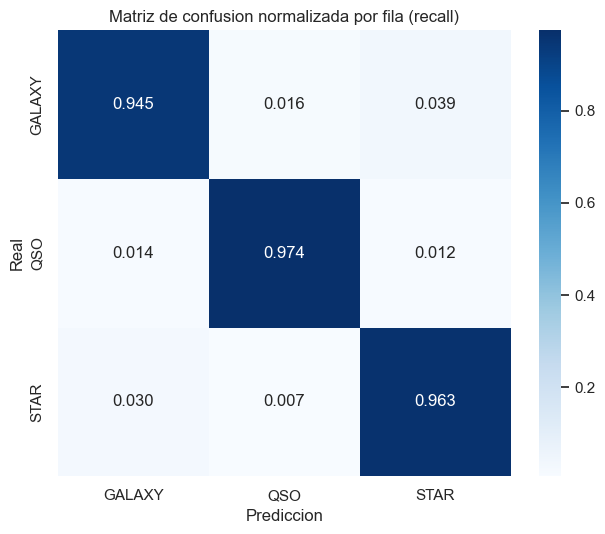

In [4]:
print("Classification report (ultimo fold):\n")
print(classification_report(last_val_y, last_val_preds, target_names=CLASS_ORDER, digits=4))

cm = confusion_matrix(last_val_y, last_val_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set_xlabel("Prediccion"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusion normalizada por fila (recall)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Modelo Final — Entrenamiento sobre todo el Train

In [5]:
pool_full = Pool(X_train, y, cat_features=cat_feature_indices)
final_model = CatBoostClassifier(**PARAMS)
final_model.fit(pool_full, verbose=False)
print("Modelo final entrenado sobre", X_train.shape[0], "filas.")

Modelo final entrenado sobre 577347 filas.


## 5. Feature Importance

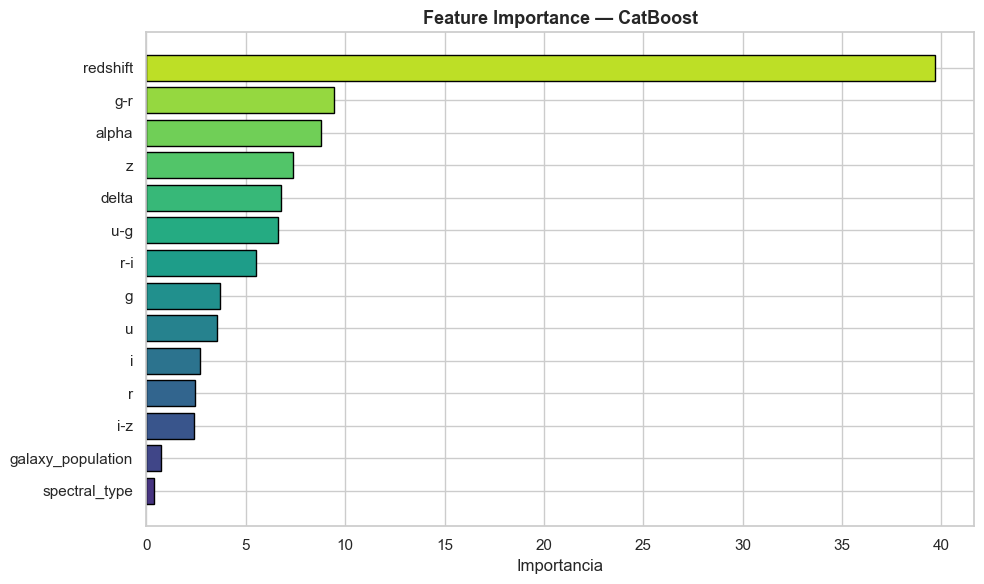

Top features:
redshift             39.66
g-r                   9.42
alpha                 8.79
z                     7.36
delta                 6.78
u-g                   6.63
r-i                   5.50
g                     3.71
u                     3.54
i                     2.69
r                     2.45
i-z                   2.38
galaxy_population     0.72
spectral_type         0.37


In [6]:
importances = final_model.get_feature_importance(pool_full)
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.viridis(np.linspace(0.15, 0.9, len(feat_imp)))
ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor="black")
ax.set_xlabel("Importancia")
ax.set_title("Feature Importance — CatBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top features:")
print(feat_imp.sort_values(ascending=False).round(2).to_string())

## 6. Predicción sobre Test y Submission

In [7]:
import os

pool_test = Pool(X_test, cat_features=cat_feature_indices)
test_preds = final_model.predict(pool_test).astype(int).ravel()
test_labels = [INV_MAP[i] for i in test_preds]

submission = pd.DataFrame({"id": ids_test, TARGET: test_labels})
submission_path = "../data/3_catboost_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"{'='*65}")
print("SUBMISSION GENERADA")
print(f"{'='*65}")
print(f"Archivo: {os.path.abspath(submission_path)}")
print(f"Filas:   {len(submission):,}")
print(f"\nDistribucion predicha (test) vs train:")
pred_dist  = pd.Series(test_labels).value_counts(normalize=True).reindex(CLASS_ORDER)
train_dist = train_raw[TARGET].value_counts(normalize=True).reindex(CLASS_ORDER)
for cls in CLASS_ORDER:
    print(f"  {cls:8s}: test {pred_dist[cls]*100:5.2f}%   |   train {train_dist[cls]*100:5.2f}%")
print(f"\nPrimeras filas:")
print(submission.head().to_string(index=False))
print(f"{'='*65}")

SUBMISSION GENERADA
Archivo: C:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\DGKaggle\Playground Series\Season 6\Episode 6 - Predicting Stellar Class\data\3_catboost_submission.csv
Filas:   247,435

Distribucion predicha (test) vs train:


  GALAXY  : test 62.64%   |   train 65.38%
  QSO     : test 20.89%   |   train 20.29%
  STAR    : test 16.47%   |   train 14.33%

Primeras filas:
    id  class
577347 GALAXY
577348 GALAXY
577349 GALAXY
577350   STAR
577351 GALAXY


In [8]:
# Chequeo de sanidad contra sample_submission (formato e ids)
sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "ids no alineados"
assert set(submission[TARGET].unique()).issubset(set(CLASS_ORDER)), "etiquetas invalidas"
print("OK: formato, ids y etiquetas validos.")

OK: formato, ids y etiquetas validos.


## 7. Envío a Kaggle vía API

In [ ]:
import sys, os, ssl, subprocess
!{sys.executable} -m pip install --upgrade kaggle --quiet

# --- Fix SSL CERTIFICATE_VERIFY_FAILED en api.kaggle.com ---
# En este equipo un proxy/antivirus intercepta TLS e inyecta una root CA que no esta
# en el bundle de certifi. Se construye un bundle combinando certifi + el almacen de
# certificados de Windows (que SI confia en esa root) y se apunta requests/ssl a el.
import certifi
bundle_path = os.path.join(os.path.dirname(certifi.where()), "win_ca_bundle.pem")
with open(bundle_path, "w", encoding="utf-8") as out:
    out.write(open(certifi.where(), encoding="utf-8").read())
    ps = (
        "$s=@('Cert:\\LocalMachine\\Root','Cert:\\CurrentUser\\Root',"
        "'Cert:\\LocalMachine\\CA','Cert:\\CurrentUser\\CA');"
        "foreach($p in $s){try{Get-ChildItem $p -EA Stop|%{"
        "'-----BEGIN CERTIFICATE-----';"
        "[Convert]::ToBase64String($_.RawData,'InsertLineBreaks');"
        "'-----END CERTIFICATE-----'}}catch{}}"
    )
    win = subprocess.run(["powershell", "-NoProfile", "-Command", ps],
                         capture_output=True, text=True)
    out.write("\n" + win.stdout)

for var in ("REQUESTS_CA_BUNDLE", "SSL_CERT_FILE", "CURL_CA_BUNDLE"):
    os.environ[var] = bundle_path
print("CA bundle listo:", bundle_path)

In [10]:
COMPETITION = "playground-series-s6e6"
FILE        = "../data/3_catboost_submission.csv"
MSG         = f"CatBoost balanced - colores + cat nativas - CV BalAcc={cv_mean:.4f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/competitions.CompetitionApiService/StartSubmissionUpload (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))


In [11]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e6

HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/competitions.CompetitionApiService/ListSubmissions (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))
